(mmm_funnel_from_yml)=
# Building funnel-aware MMMs from YAML

This notebook shows that complex funnel MMMs can be declared in YAML and built with `build_mmm_from_yaml`. It mirrors the model specs from {ref}`mmm_funnel_mueffect` (intro) and {ref}`mmm_funnel_mueffect_advanced` (geo panel).

For each spec we show three views:

1. **Causal DAG** — what the specification claims about the world (hand-drawn for now; see issue #2886)
2. **YAML** — the configuration file
3. **PyMC graph** — the computational graph the builder produces

```{important}
`FunnelEffect` and `GeoFunnelEffect` are defined **in this notebook** (not in the library yet). YAML references them through short names registered on `REGISTRY`.
```

```{note}
**Reading the causal DAGs.** Grey-filled nodes are observed. Dashed-outline nodes are latent. Dashed/dotted edges mark measurement or indicator links.
```


In [1]:
import warnings
from pathlib import Path

import graphviz as gr
import numpy as np
import pandas as pd
import pymc.dims as pmd
import xarray as xr
from IPython.display import Markdown, display
from pydantic import InstanceOf

from pymc_marketing.mmm import (
    AdstockTransformation,
    SaturationTransformation,
)
from pymc_marketing.mmm.additive_effect import (
    DataVarMuEffect,
    IncrementalitySpec,
)
from pymc_marketing.mmm.builders.factories import REGISTRY
from pymc_marketing.mmm.builders.yaml import build_mmm_from_yaml
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore")
CONFIG_DIR = data_dir / "config_files"


def show_yaml(path: Path) -> None:
    """Print a YAML config so readers can follow along in the notebook."""
    text = path.read_text()
    display(Markdown(f"**`{path.name}`**\n\n```yaml\n{text}```"))


def show_graph(mmm, title: str | None = None) -> None:
    """Display the PyMC graph built from a YAML spec."""
    if title:
        display(Markdown(f"**{title}** — PyMC graph"))
    display(mmm.graphviz())


def _node_attrs(kind: str) -> dict:
    if kind == "observed":
        return {"style": "filled", "fillcolor": "lightgray", "shape": "ellipse"}
    if kind == "latent":
        return {"style": "dashed", "shape": "ellipse"}
    raise ValueError(kind)


def draw_causal_dag(
    nodes: list[tuple[str, str, str]],
    edges: list,
    *,
    title: str | None = None,
    rankdir: str = "LR",
) -> gr.Digraph:
    """Hand-drawn causal DAG. kind is 'observed' or 'latent'."""
    g = gr.Digraph()
    g.attr(rankdir=rankdir)
    if title:
        g.attr(label=title, labelloc="t", fontsize="14")
    for node_id, label, kind in nodes:
        g.node(node_id, label, **_node_attrs(kind))
    for edge in edges:
        if len(edge) == 2:
            g.edge(edge[0], edge[1])
        else:
            g.edge(edge[0], edge[1], **edge[2])
    return g


def show_causal_dag(*args, **kwargs) -> None:
    display(draw_causal_dag(*args, **kwargs))

/Users/benjamv/wt/pymc-marketing/funnel-from-yaml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Custom funnel effects

YAML `effects:` entries reference Python classes registered on `REGISTRY`. We port the effect logic from the hand-wired notebooks here.


In [2]:
class FunnelEffect(DataVarMuEffect):
    """Intro-topology funnel effect (ported from mmm_funnel_mueffect)."""

    data_vars: list[str] = ["lower_spend", "lower_control"]
    prefix: str = "funnel"
    adstock_uf: InstanceOf[AdstockTransformation]
    saturation_uf: InstanceOf[SaturationTransformation]
    adstock_lf: InstanceOf[AdstockTransformation]
    saturation_lf: InstanceOf[SaturationTransformation]

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "prefix": self.prefix,
            "data_vars": list(self.data_vars),
            "adstock_uf": self.adstock_uf.to_dict(),
            "saturation_uf": self.saturation_uf.to_dict(),
            "adstock_lf": self.adstock_lf.to_dict(),
            "saturation_lf": self.saturation_lf.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec()

    def create_effect(self, mmm):
        """Build the intro funnel subgraph."""
        model = mmm.model
        upper = mmm.channel_data_scaled.isel(channel=0)
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0)
        upper_on_lower = self.saturation_uf.apply(
            self.adstock_uf.apply(upper, core_dim="date"), core_dim="date"
        )
        demand = pmd.Deterministic(
            f"{self.prefix}_lower_demand",
            baseline + gamma * model["lower_control"] + upper_on_lower,
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_likelihood",
            mu=demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma", sigma=1.0),
            lower=0.0,
            observed=model["lower_spend"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.saturation_lf.apply(
                self.adstock_lf.apply(demand, core_dim="date"), core_dim="date"
            ),
        )


class GeoFunnelEffect(DataVarMuEffect):
    """Advanced geo-panel funnel effect (ported from mmm_funnel_mueffect_advanced)."""

    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec(
            additional_carryover_lags=self.demand_transform.adstock.l_max
        )

    def create_effect(self, mmm):
        """Build the geo funnel subgraph."""
        model = mmm.model
        upper_on_demand = self.upper_transform(mmm.channel_data_scaled, dim="date").sum(
            dim="channel"
        )
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0, dims=("geo",))
        demand = pmd.Deterministic(
            f"{self.prefix}_demand",
            baseline + gamma * model["category_demand"] + upper_on_demand,
        )
        lam_b = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5, dims=("geo",))
        lf_spend = pmd.Deterministic(
            f"{self.prefix}_lf_spend",
            demand + lam_b * model["lf_budget"],
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_spend_likelihood",
            mu=lf_spend,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_m", sigma=1.0, dims=("geo",)),
            lower=0.0,
            observed=model["lower_spend"],
        )
        kappa = pmd.HalfNormal(f"{self.prefix}_kappa", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_search_likelihood",
            mu=kappa * demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_s", sigma=1.0, dims=("geo",)),
            observed=model["search_volume"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(lf_spend, dim="date"),
        )


REGISTRY["FunnelEffect"] = FunnelEffect
REGISTRY["GeoFunnelEffect"] = GeoFunnelEffect

## Part 1 — Intro funnel (national)

Three specs from {ref}`mmm_funnel_mueffect`:

| Model | YAML idea |
|-------|-----------|
| **Naive A** | `lower_spend` in `channel_columns` |
| **Naive B** | upper funnel only |
| **Funnel** | `effects: [FunnelEffect]` + `extra_vars` |


### True funnel structure

The causal DAG the funnel YAML is meant to encode:


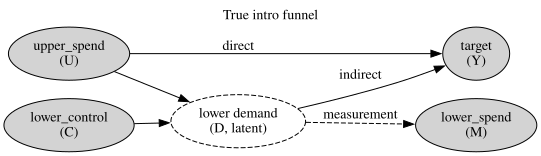

In [3]:
show_causal_dag(
    [
        ("U", "upper_spend\n(U)", "observed"),
        ("C", "lower_control\n(C)", "observed"),
        ("D", "lower demand\n(D, latent)", "latent"),
        ("M", "lower_spend\n(M)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y", {"label": "direct"}),
        ("U", "D"),
        ("C", "D"),
        ("D", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "Y", {"label": "indirect"}),
    ],
    title="True intro funnel",
)

In [4]:
n_dates = 10
dates = pd.date_range("2021-01-04", periods=n_dates, freq="W-MON")
X_intro = pd.DataFrame(
    {
        "date": dates,
        "upper_spend": np.ones(n_dates),
        "lower_spend": np.ones(n_dates),
    }
)
y_intro = np.ones(n_dates)

X_funnel_intro = xr.Dataset(
    {
        "media": xr.DataArray(
            X_intro[["upper_spend"]].to_numpy(),
            dims=("date", "channel"),
            coords={"date": dates.to_numpy(), "channel": ["upper_spend"]},
        ),
        "lower_spend": ("date", np.ones(n_dates)),
        "lower_control": ("date", np.ones(n_dates)),
    }
)

### Build models

Causal DAG → YAML → PyMC graph. Placeholder `X`/`y` supply the right columns and dims; no fitting.


#### Naive A — lower spend as a regular channel

Both `upper_spend` and `lower_spend` in `channel_columns`.


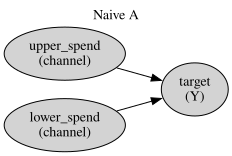

In [5]:
show_causal_dag(
    [
        ("U", "upper_spend\n(channel)", "observed"),
        ("M", "lower_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [("U", "Y"), ("M", "Y")],
    title="Naive A",
)

In [6]:
show_yaml(CONFIG_DIR / "funnel_intro_naive_a.yml")
m_naive_a = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_intro_naive_a.yml", X=X_intro, y=y_intro
)

**`funnel_intro_naive_a.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend, lower_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive A** — PyMC graph

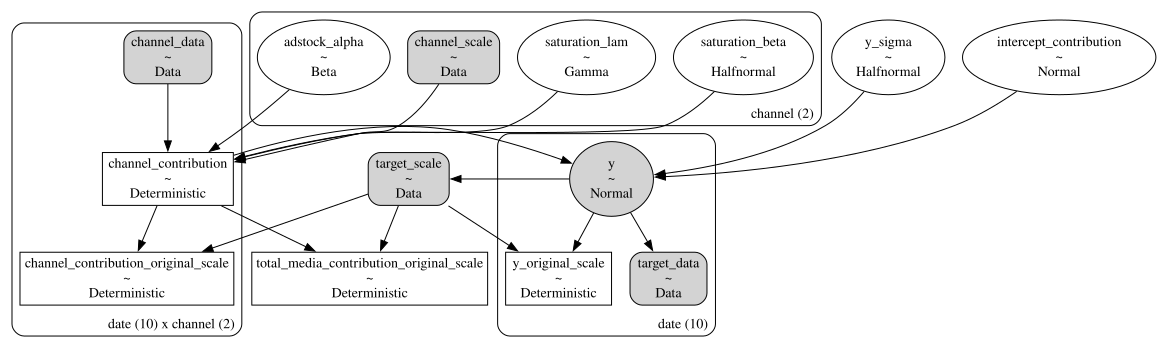

In [7]:
show_graph(m_naive_a, "Naive A")

#### Naive B — upper funnel only

Only `upper_spend` is a channel.


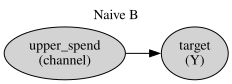

In [8]:
show_causal_dag(
    [("U", "upper_spend\n(channel)", "observed"), ("Y", "target\n(Y)", "observed")],
    [("U", "Y")],
    title="Naive B",
)

In [9]:
show_yaml(CONFIG_DIR / "funnel_intro_naive_b.yml")
m_naive_b = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_intro_naive_b.yml", X=X_intro, y=y_intro
)

**`funnel_intro_naive_b.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B** — PyMC graph

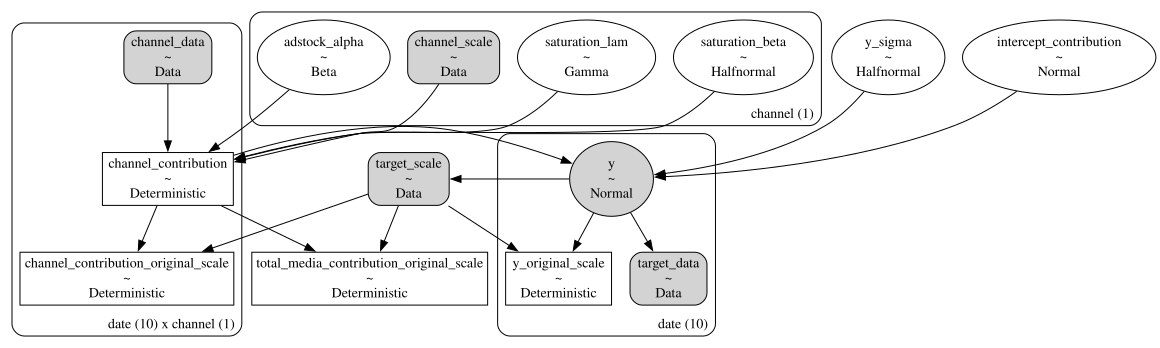

In [10]:
show_graph(m_naive_b, "Naive B")

#### Funnel — structural mediation via `FunnelEffect`

`effects:` adds demand, a lower-funnel likelihood, and mediated contribution. `extra_vars` keeps mediators in the dataset.


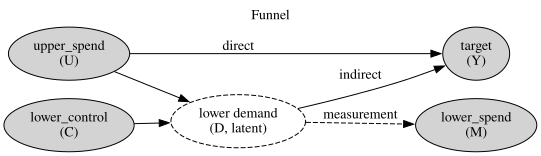

In [11]:
show_causal_dag(
    [
        ("U", "upper_spend\n(U)", "observed"),
        ("C", "lower_control\n(C)", "observed"),
        ("D", "lower demand\n(D, latent)", "latent"),
        ("M", "lower_spend\n(M)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y", {"label": "direct"}),
        ("U", "D"),
        ("C", "D"),
        ("D", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "Y", {"label": "indirect"}),
    ],
    title="Funnel",
)

In [12]:
show_yaml(CONFIG_DIR / "funnel_intro.yml")
m_funnel = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_intro.yml", X=X_funnel_intro, y=y_intro
)

**`funnel_intro.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, lower_control]

effects:
  - class: FunnelEffect
    kwargs:
      adstock_uf:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_uf}
      saturation_uf:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_uf}
      adstock_lf:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_lf}
      saturation_lf:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_lf}

original_scale_vars: [channel_contribution, funnel_effect_contribution, y]
```

**Funnel** — PyMC graph

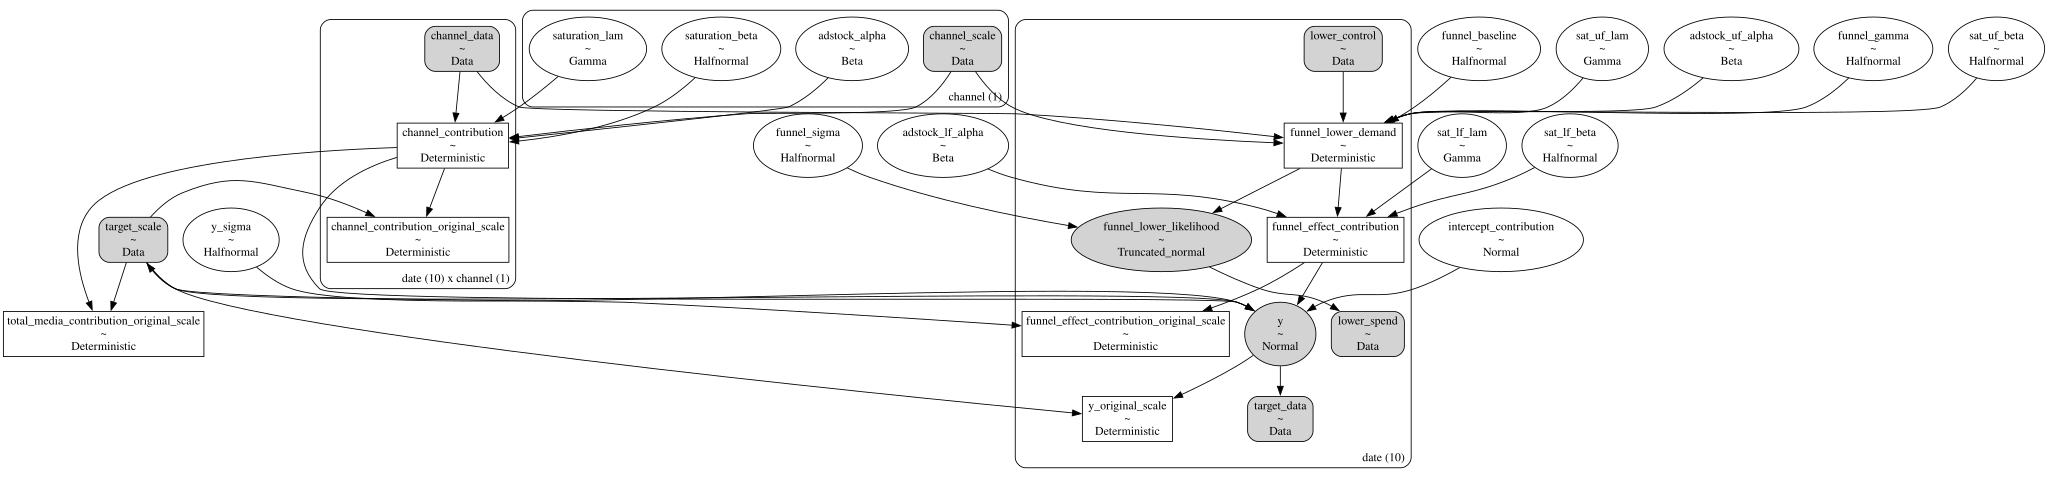

In [13]:
show_graph(m_funnel, "Funnel")

## Part 2 — Advanced funnel (geo panel)

Six specs from {ref}`mmm_funnel_mueffect_advanced` — same three-step comparison.


### True geo funnel structure


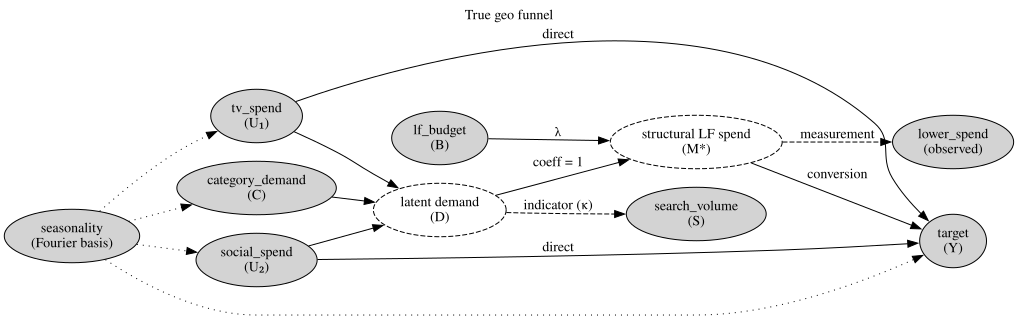

In [14]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(U₁)", "observed"),
        ("U2", "social_spend\n(U₂)", "observed"),
        ("C", "category_demand\n(C)", "observed"),
        ("B", "lf_budget\n(B)", "observed"),
        ("D", "latent demand\n(D)", "latent"),
        ("MS", "structural LF spend\n(M*)", "latent"),
        ("M", "lower_spend\n(observed)", "observed"),
        ("S", "search_volume\n(S)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "U1", {"style": "dotted"}),
        ("season", "U2", {"style": "dotted"}),
        ("season", "C", {"style": "dotted"}),
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y", {"label": "direct"}),
        ("U2", "Y", {"label": "direct"}),
        ("U1", "D"),
        ("U2", "D"),
        ("C", "D"),
        ("D", "MS", {"label": "coeff = 1"}),
        ("B", "MS", {"label": "λ"}),
        ("MS", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
        ("MS", "Y", {"label": "conversion"}),
    ],
    title="True geo funnel",
)

In [15]:
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]
dates_adv = pd.date_range("2021-01-04", periods=n_dates, freq="W-MON")
rows = [
    {
        "date": date,
        "geo": geo,
        "tv_spend": 1.0,
        "social_spend": 1.0,
        "category_demand": 1.0,
        "t": 0.5,
    }
    for date in dates_adv
    for geo in geos
]
df_adv = pd.DataFrame(rows)
df_naive_a = df_adv.assign(lower_spend=1.0)
df_naive_c = df_adv.assign(search_volume=1.0)
y_adv = np.ones(len(df_adv))
y_build = xr.DataArray(
    np.ones((n_dates, len(geos))),
    dims=("date", "geo"),
    coords={"date": dates_adv.to_numpy(), "geo": geos},
)
ds_funnel = xr.Dataset(
    {
        "media": xr.DataArray(
            np.ones((n_dates, len(geos), len(channels))),
            dims=("date", "geo", "channel"),
            coords={"date": dates_adv.to_numpy(), "geo": geos, "channel": channels},
        ),
        "lower_spend": (("date", "geo"), np.ones((n_dates, len(geos)))),
        "search_volume": (("date", "geo"), np.ones((n_dates, len(geos)))),
        "category_demand": (("date", "geo"), np.ones((n_dates, len(geos)))),
        "lf_budget": (("date", "geo"), np.ones((n_dates, len(geos)))),
    }
)

### Build models


#### Naive A

Adds `lower_spend` as a third channel.


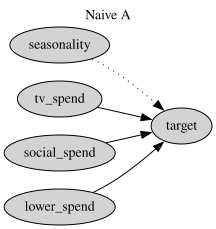

In [16]:
show_causal_dag(
    [
        ("season", "seasonality", "observed"),
        ("U1", "tv_spend", "observed"),
        ("U2", "social_spend", "observed"),
        ("M", "lower_spend", "observed"),
        ("Y", "target", "observed"),
    ],
    [("season", "Y", {"style": "dotted"}), ("U1", "Y"), ("U2", "Y"), ("M", "Y")],
    title="Naive A",
)

In [17]:
show_yaml(CONFIG_DIR / "funnel_advanced_naive_a.yml")
m_adv_naive_a = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_advanced_naive_a.yml", X=df_naive_a, y=y_adv
)

**`funnel_advanced_naive_a.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend, lower_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive A** — PyMC graph

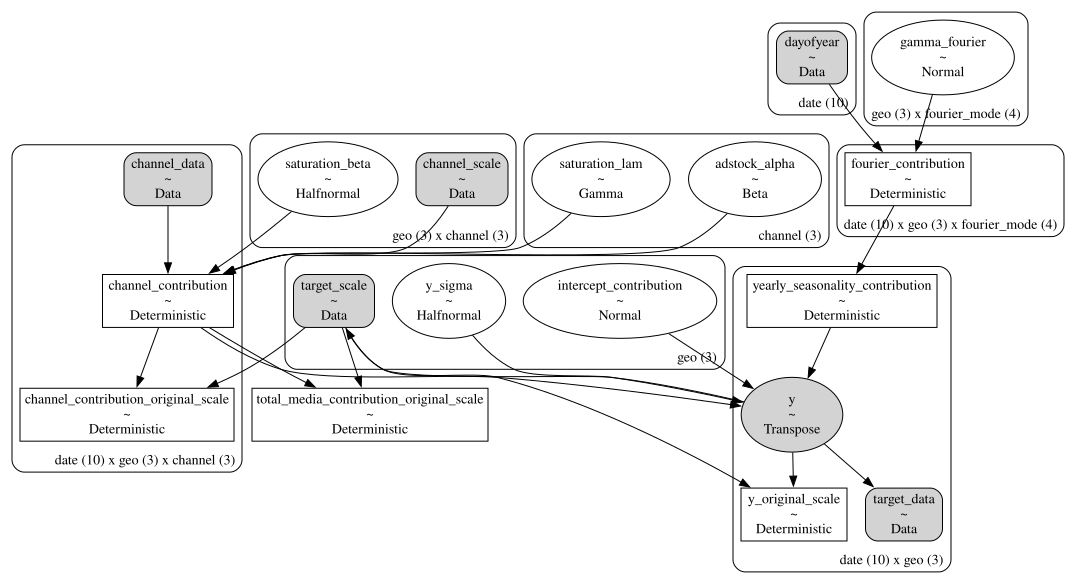

In [18]:
show_graph(m_adv_naive_a, "Naive A")

#### Naive B

Upper channels only.


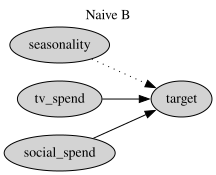

In [19]:
show_causal_dag(
    [
        ("season", "seasonality", "observed"),
        ("U1", "tv_spend", "observed"),
        ("U2", "social_spend", "observed"),
        ("Y", "target", "observed"),
    ],
    [("season", "Y", {"style": "dotted"}), ("U1", "Y"), ("U2", "Y")],
    title="Naive B",
)

In [20]:
show_yaml(CONFIG_DIR / "funnel_advanced_naive_b.yml")
m_adv_naive_b = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_advanced_naive_b.yml", X=df_adv, y=y_adv
)

**`funnel_advanced_naive_b.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B** — PyMC graph

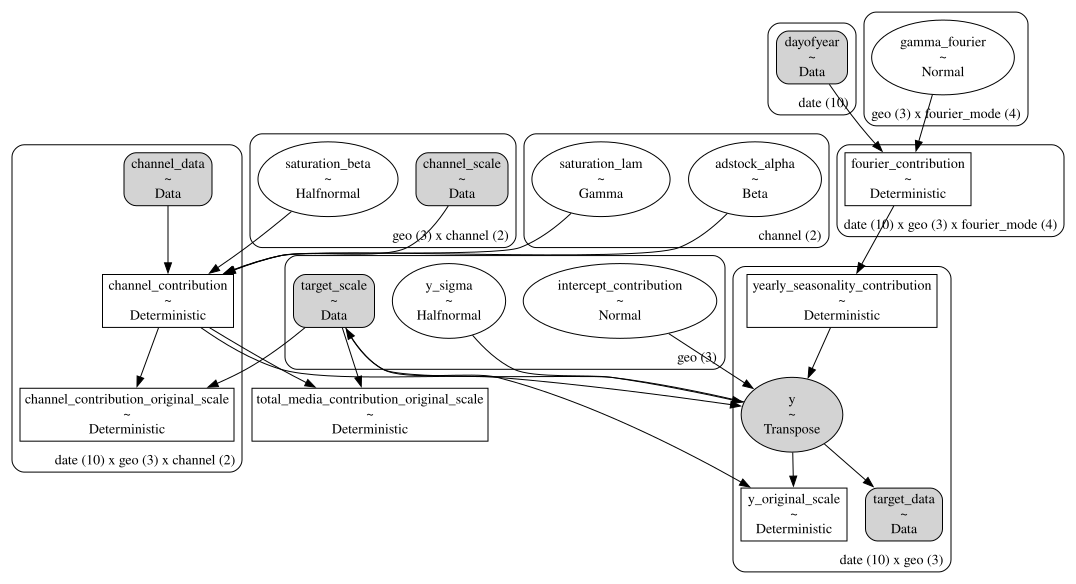

In [21]:
show_graph(m_adv_naive_b, "Naive B")

#### Naive B+

Adds `category_demand` as a control.


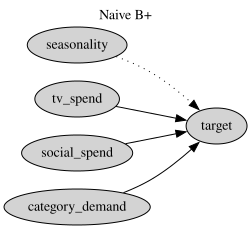

In [22]:
show_causal_dag(
    [
        ("season", "seasonality", "observed"),
        ("U1", "tv_spend", "observed"),
        ("U2", "social_spend", "observed"),
        ("C", "category_demand", "observed"),
        ("Y", "target", "observed"),
    ],
    [("season", "Y", {"style": "dotted"}), ("U1", "Y"), ("U2", "Y"), ("C", "Y")],
    title="Naive B+",
)

In [23]:
show_yaml(CONFIG_DIR / "funnel_advanced_naive_bplus.yml")
m_adv_naive_bplus = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_advanced_naive_bplus.yml", X=df_adv, y=y_adv
)

**`funnel_advanced_naive_bplus.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    control_columns: [category_demand]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B+** — PyMC graph

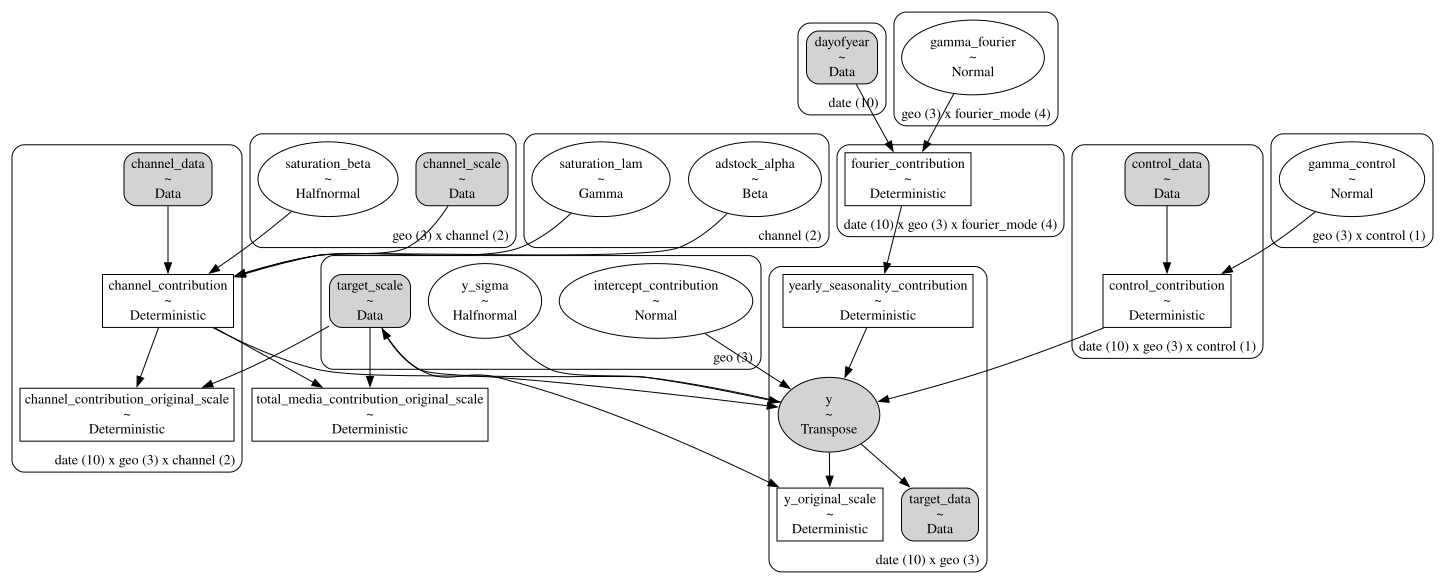

In [24]:
show_graph(m_adv_naive_bplus, "Naive B+")

#### Naive B++

Adds time trend `t` as a control.


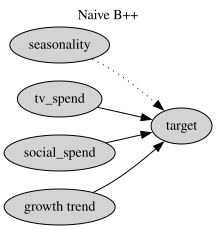

In [25]:
show_causal_dag(
    [
        ("season", "seasonality", "observed"),
        ("U1", "tv_spend", "observed"),
        ("U2", "social_spend", "observed"),
        ("t", "growth trend", "observed"),
        ("Y", "target", "observed"),
    ],
    [("season", "Y", {"style": "dotted"}), ("U1", "Y"), ("U2", "Y"), ("t", "Y")],
    title="Naive B++",
)

In [26]:
show_yaml(CONFIG_DIR / "funnel_advanced_naive_bpp.yml")
m_adv_naive_bpp = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_advanced_naive_bpp.yml", X=df_adv, y=y_adv
)

**`funnel_advanced_naive_bpp.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    control_columns: [t]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B++** — PyMC graph

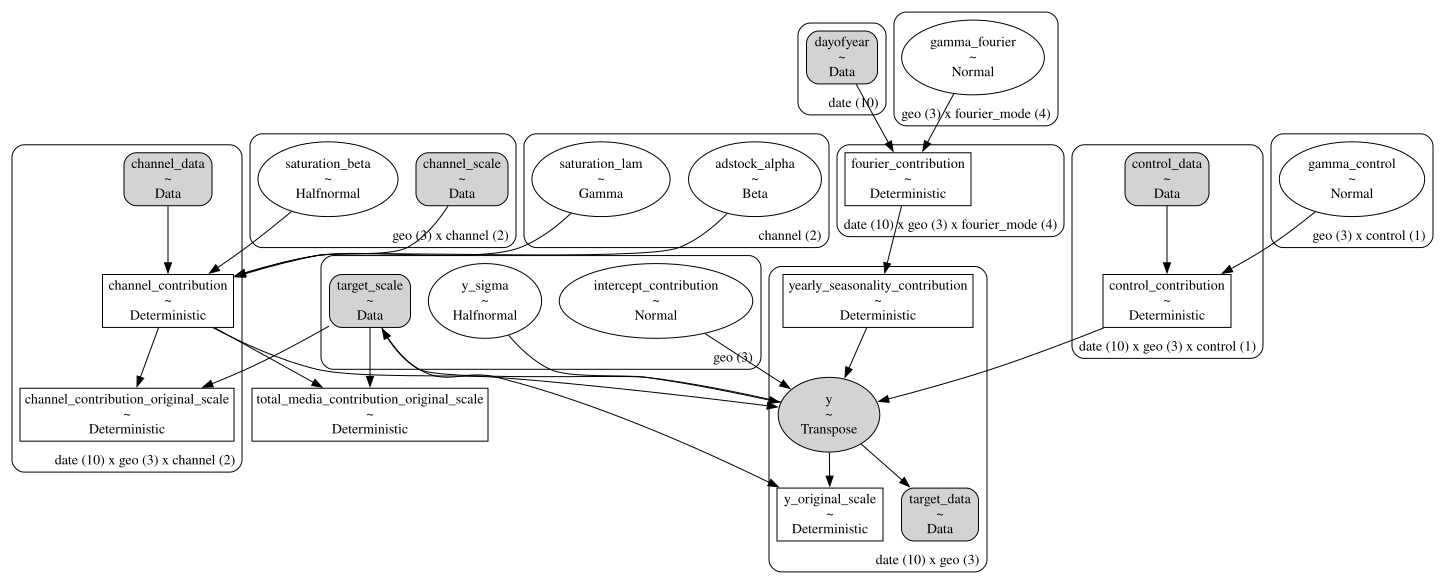

In [27]:
show_graph(m_adv_naive_bpp, "Naive B++")

#### Naive C

Puts `search_volume` in `channel_columns`.


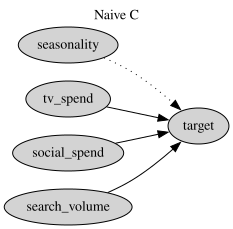

In [28]:
show_causal_dag(
    [
        ("season", "seasonality", "observed"),
        ("U1", "tv_spend", "observed"),
        ("U2", "social_spend", "observed"),
        ("S", "search_volume", "observed"),
        ("Y", "target", "observed"),
    ],
    [("season", "Y", {"style": "dotted"}), ("U1", "Y"), ("U2", "Y"), ("S", "Y")],
    title="Naive C",
)

In [29]:
show_yaml(CONFIG_DIR / "funnel_advanced_naive_c.yml")
m_adv_naive_c = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_advanced_naive_c.yml", X=df_naive_c, y=y_adv
)

**`funnel_advanced_naive_c.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend, search_volume]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive C** — PyMC graph

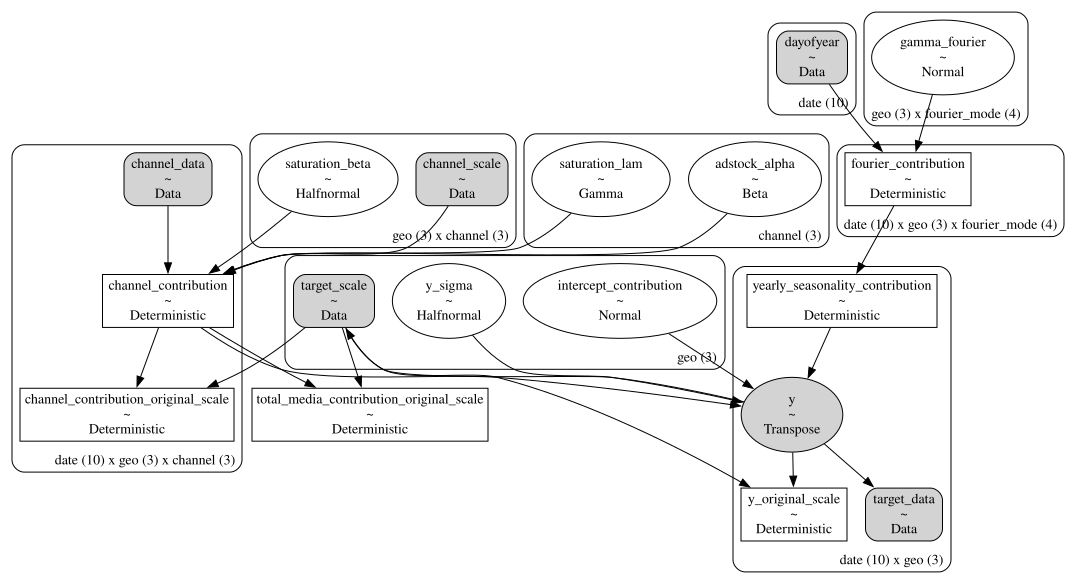

In [30]:
show_graph(m_adv_naive_c, "Naive C")

#### Funnel

`GeoFunnelEffect` with extra likelihoods and `extra_vars`.


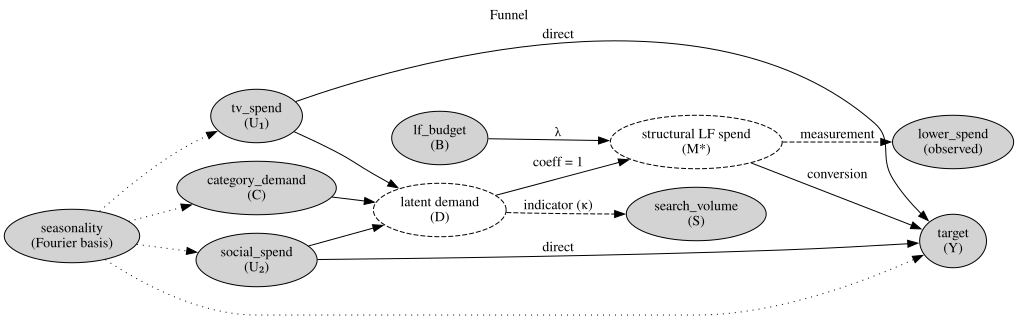

In [31]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(U₁)", "observed"),
        ("U2", "social_spend\n(U₂)", "observed"),
        ("C", "category_demand\n(C)", "observed"),
        ("B", "lf_budget\n(B)", "observed"),
        ("D", "latent demand\n(D)", "latent"),
        ("MS", "structural LF spend\n(M*)", "latent"),
        ("M", "lower_spend\n(observed)", "observed"),
        ("S", "search_volume\n(S)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "U1", {"style": "dotted"}),
        ("season", "U2", {"style": "dotted"}),
        ("season", "C", {"style": "dotted"}),
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y", {"label": "direct"}),
        ("U2", "Y", {"label": "direct"}),
        ("U1", "D"),
        ("U2", "D"),
        ("C", "D"),
        ("D", "MS", {"label": "coeff = 1"}),
        ("B", "MS", {"label": "λ"}),
        ("MS", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
        ("MS", "Y", {"label": "conversion"}),
    ],
    title="Funnel",
)

In [32]:
show_yaml(CONFIG_DIR / "funnel_advanced.yml")
m_adv_funnel = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_advanced.yml", X=ds_funnel, y=y_build
)

**`funnel_advanced.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, search_volume, category_demand, lf_budget]

effects:
  - class: GeoFunnelEffect
    kwargs:
      data_vars: [lower_spend, search_volume, category_demand, lf_budget]
      prefix: funnel
      upper_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo, channel]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_uf
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: channel
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_uf
              priors:
                lam:
                  distribution: Gamma
                  mu: 2.0
                  sigma: 1.0
                  dims: channel
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: [geo, channel]
      demand_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_lf
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: geo
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_lf
              priors:
                lam:
                  distribution: Gamma
                  mu: 1.5
                  sigma: 0.5
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: geo

original_scale_vars: [channel_contribution, funnel_effect_contribution, y]
```

**Funnel** — PyMC graph

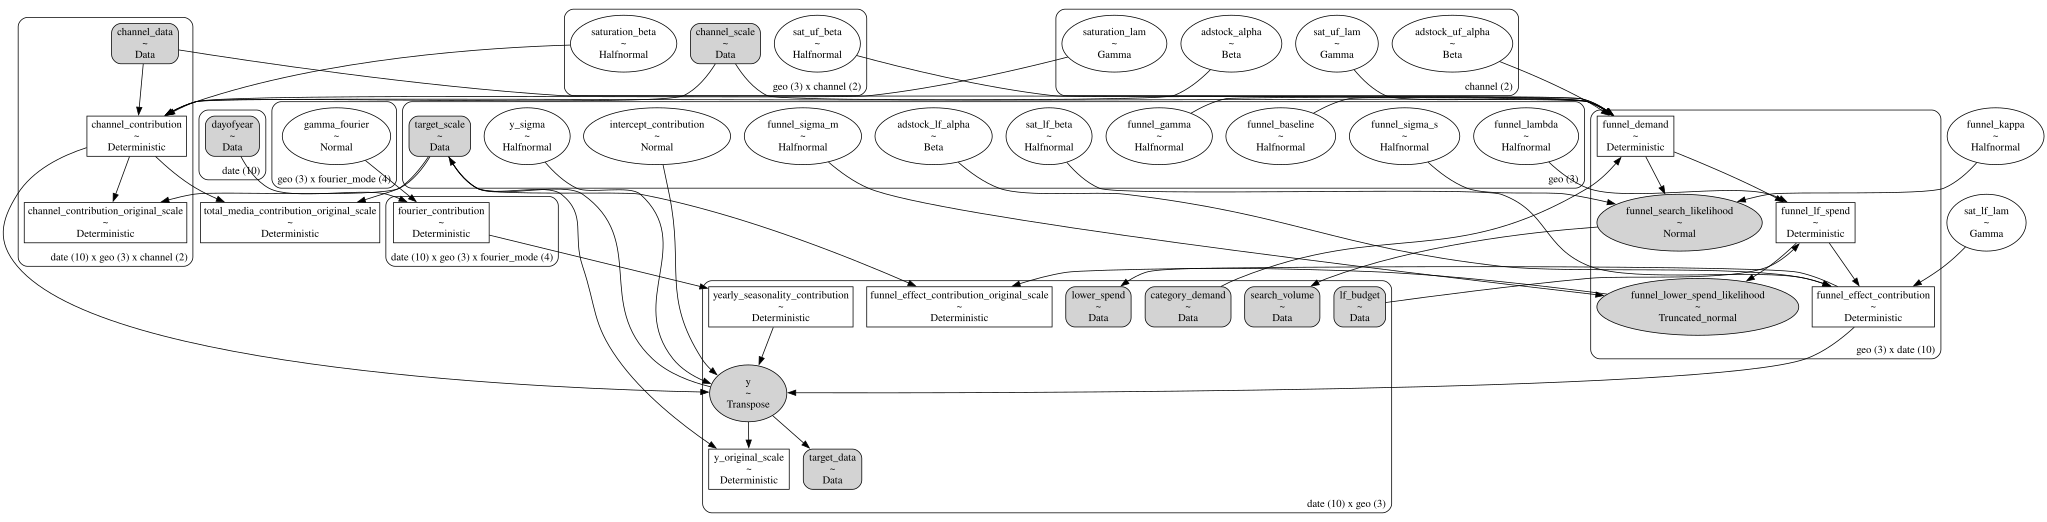

In [33]:
show_graph(m_adv_funnel, "Funnel")

## Summary

- YAML `model:` covers standard MMM kwargs; `effects:` and `extra_vars` extend the graph for funnel structure.
- Causal DAG → YAML → PyMC graph is the comparison loop; fitting and ROAS live in the upstream notebooks.
- Promoting `FunnelEffect` / `GeoFunnelEffect` into the library is the natural next step.


In [34]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Mon, 17 Aug 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

IPython       : 9.15.0
graphviz      : 0.21
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_marketing: 1.0.0
xarray        : 2026.4.0

Watermark: 2.6.0

